In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch

In [15]:
web = cv2.imread(r"C:\Users\adamain\Downloads\spider_web.png")
web =  cv2.cvtColor(web, cv2.COLOR_BGR2RGB)
edited = cv2.imread(r"C:\Users\adamain\Documents\Annotated Spiders\cropped_19 - 1_web_annotated.png")
edited =  cv2.cvtColor(edited, cv2.COLOR_BGR2RGB)

In [16]:
def imshow(image, title = "Image", axis = "off", cmap = 'gray'):
    plt.imshow(image, cmap = cmap)
    plt.axis(axis)
    plt.title(title)
    plt.tight_layout()
    plt.show()

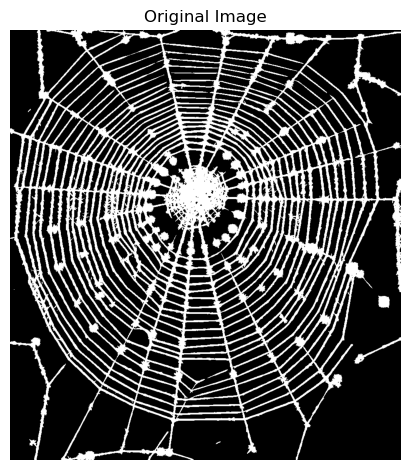

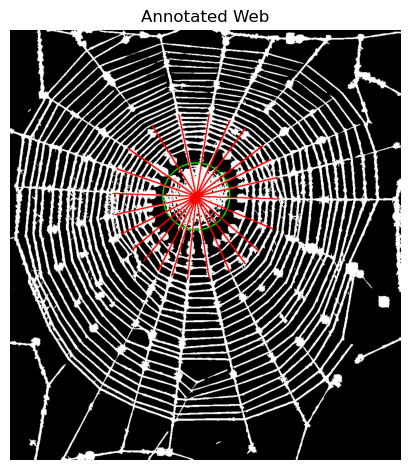

In [18]:
imshow(web, title = "Original Image")
imshow(edited, title = "Annotated Web")

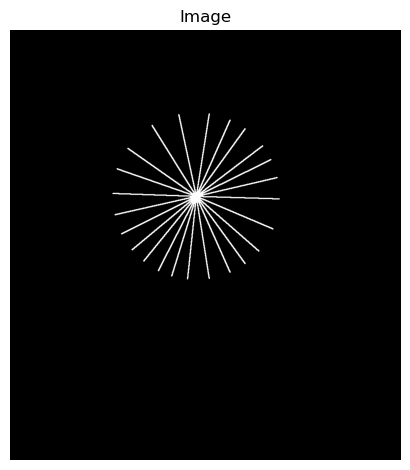

In [22]:
# Convert RGB -> HSV
image_bgr = cv2.cvtColor(edited, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

# Red color in HSV (wraps around)
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)
imshow(mask)
    

In [24]:
import numpy as np
import cv2
from scipy import ndimage
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def analyze_radial_lines(mask):
    """
    Analyze radial lines in a binary mask using polar coordinate analysis.
    
    Parameters:
    mask (numpy.ndarray): Binary mask with radial lines
    
    Returns:
    dict: Dictionary containing angles, analysis results
    """
    
    # Ensure mask is binary
    if len(mask.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    
    if mask.max() > 1:
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    else:
        binary = (mask * 255).astype(np.uint8)
    
    # Find center more accurately
    center = find_center_accurately(binary)
    
    # Use polar coordinate analysis to find radial lines
    angles = find_radial_lines_polar(binary, center)
    
    # Calculate angle differences
    angle_differences = calculate_angle_differences(angles)
    
    return {
        'center': center,
        'angles': angles,
        'angle_differences': angle_differences,
        'num_lines': len(angles),
        'mean_angle_diff': np.mean(angle_differences),
        'std_angle_diff': np.std(angle_differences)
    }

def measure_radial_line_lengths(mask, center, angles):
    """
    Measure the length of each radial line in pixels.
    
    Parameters:
    mask (numpy.ndarray): Binary mask with radial lines
    center (tuple): Center point (x, y)
    angles (numpy.ndarray): Array of angles in degrees
    
    Returns:
    numpy.ndarray: Array of line lengths in pixels
    """
    
    # Ensure mask is binary
    if len(mask.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    
    if mask.max() > 1:
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    else:
        binary = (mask * 255).astype(np.uint8)
    
    cx, cy = center
    h, w = binary.shape
    lengths = []
    
    for angle in angles:
        angle_rad = np.radians(angle)
        cos_angle = np.cos(angle_rad)
        sin_angle = np.sin(angle_rad)
        
        # Find the extent of the line in both directions from center
        max_radius = min(w, h) // 2 + 100  # Conservative maximum
        
        # Search in positive direction
        line_pixels_positive = []
        for r in range(1, max_radius):
            x = int(cx + r * cos_angle)
            y = int(cy + r * sin_angle)
            
            # Check if point is within image bounds
            if 0 <= x < w and 0 <= y < h:
                # Check if this pixel or nearby pixels are part of the line
                found_pixel = False
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx] > 0:
                            line_pixels_positive.append(r)
                            found_pixel = True
                            break
                    if found_pixel:
                        break
            else:
                break
        
        # Search in negative direction
        line_pixels_negative = []
        for r in range(1, max_radius):
            x = int(cx - r * cos_angle)
            y = int(cy - r * sin_angle)
            
            # Check if point is within image bounds
            if 0 <= x < w and 0 <= y < h:
                # Check if this pixel or nearby pixels are part of the line
                found_pixel = False
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx] > 0:
                            line_pixels_negative.append(r)
                            found_pixel = True
                            break
                    if found_pixel:
                        break
            else:
                break
        
        # Calculate total length as the span from furthest negative to furthest positive
        if line_pixels_positive and line_pixels_negative:
            # Line extends in both directions
            total_length = max(line_pixels_positive) + max(line_pixels_negative)
        elif line_pixels_positive:
            # Line only extends in positive direction
            total_length = max(line_pixels_positive)
        elif line_pixels_negative:
            # Line only extends in negative direction
            total_length = max(line_pixels_negative)
        else:
            # No line pixels found - try a more aggressive search
            total_length = measure_line_length_aggressive(binary, cx, cy, angle_rad)
        
        lengths.append(total_length)
    
    return np.array(lengths)

def measure_line_length_aggressive(binary, cx, cy, angle_rad):
    """
    More aggressive line length measurement for cases where the simple method fails.
    """
    cos_angle = np.cos(angle_rad)
    sin_angle = np.sin(angle_rad)
    h, w = binary.shape
    
    # Create a thicker sampling line
    line_pixels = []
    max_radius = min(w, h)
    
    for r in range(-max_radius//2, max_radius//2):
        x = int(cx + r * cos_angle)
        y = int(cy + r * sin_angle)
        
        if 0 <= x < w and 0 <= y < h:
            # Check a wider neighborhood (3x3)
            found = False
            for dx in [-2, -1, 0, 1, 2]:
                for dy in [-2, -1, 0, 1, 2]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < w and 0 <= ny < h and binary[ny, nx] > 0:
                        line_pixels.append(r)
                        found = True
                        break
                if found:
                    break
    
    if line_pixels:
        return max(line_pixels) - min(line_pixels)
    else:
        return 0

def find_center_accurately(binary_mask):
    """
    Find the center point more accurately using moment analysis.
    """
    # Method 1: Try to find intersection point using Hough lines
    lines = cv2.HoughLines(binary_mask, 1, np.pi/180, threshold=50)
    
    if lines is not None and len(lines) >= 2:
        # Find intersection of lines to get center
        intersections = []
        for i in range(min(10, len(lines))):  # Use first 10 lines
            for j in range(i+1, min(10, len(lines))):
                rho1, theta1 = lines[i][0]
                rho2, theta2 = lines[j][0]
                
                # Calculate intersection point
                intersection = line_intersection(rho1, theta1, rho2, theta2)
                if intersection is not None:
                    intersections.append(intersection)
        
        if intersections:
            # Use median of intersections as center
            intersections = np.array(intersections)
            center_x = np.median(intersections[:, 0])
            center_y = np.median(intersections[:, 1])
            
            # Clamp to image bounds
            h, w = binary_mask.shape
            center_x = max(0, min(w-1, center_x))
            center_y = max(0, min(h-1, center_y))
            
            return (int(center_x), int(center_y))
    
    # Method 2: Use centroid as fallback
    y_coords, x_coords = np.where(binary_mask > 0)
    if len(x_coords) > 0:
        center_x = int(np.mean(x_coords))
        center_y = int(np.mean(y_coords))
        return (center_x, center_y)
    
    # Method 3: Use image center as last resort
    return (binary_mask.shape[1] // 2, binary_mask.shape[0] // 2)

def line_intersection(rho1, theta1, rho2, theta2):
    """
    Find intersection point of two lines in polar form.
    """
    cos_theta1, sin_theta1 = np.cos(theta1), np.sin(theta1)
    cos_theta2, sin_theta2 = np.cos(theta2), np.sin(theta2)
    
    det = cos_theta1 * sin_theta2 - sin_theta1 * cos_theta2
    if abs(det) < 1e-10:
        return None  # Lines are parallel
    
    x = (sin_theta2 * rho1 - sin_theta1 * rho2) / det
    y = (cos_theta1 * rho2 - cos_theta2 * rho1) / det
    
    return (x, y)

def find_radial_lines_polar(binary_mask, center):
    """
    Find radial lines using polar coordinate analysis.
    """
    cx, cy = center
    h, w = binary_mask.shape
    
    # Create coordinate grids
    y, x = np.ogrid[:h, :w]
    
    # Convert to polar coordinates relative to center
    dx = x - cx
    dy = y - cy
    
    # Calculate angles for all pixels
    angles = np.arctan2(dy, dx)
    angles_deg = np.degrees(angles)
    angles_deg[angles_deg < 0] += 360  # Normalize to 0-360
    
    # Create angular histogram
    angle_bins = np.linspace(0, 360, 720)  # 0.5 degree resolution
    
    # Weight by pixel intensity and distance from center
    distances = np.sqrt(dx**2 + dy**2)
    weights = binary_mask.astype(float) / 255.0
    
    # Only consider pixels that are part of lines (white pixels)
    mask_pixels = binary_mask > 0
    
    if not np.any(mask_pixels):
        return np.array([])
    
    # Get angles and weights for line pixels only
    line_angles = angles_deg[mask_pixels]
    line_weights = weights[mask_pixels]
    
    # Create weighted histogram
    hist, bin_edges = np.histogram(line_angles, bins=angle_bins, weights=line_weights)
    
    # Smooth the histogram to reduce noise
    hist_smooth = ndimage.gaussian_filter1d(hist, sigma=2)
    
    # Find peaks in the histogram
    # Use adaptive threshold based on histogram statistics
    threshold = np.mean(hist_smooth) + 2 * np.std(hist_smooth)
    peaks, properties = find_peaks(hist_smooth, 
                                  height=threshold,
                                  distance=10,  # Minimum 5 degrees between peaks
                                  prominence=np.max(hist_smooth) * 0.1)
    
    # Convert peak indices back to angles
    peak_angles = bin_edges[peaks]
    
    # Sort angles
    peak_angles = np.sort(peak_angles)
    
    # If we didn't find enough peaks, try with lower threshold
    if len(peak_angles) < 20:  # Expecting around 24 lines
        threshold = np.mean(hist_smooth) + np.std(hist_smooth)
        peaks, properties = find_peaks(hist_smooth, 
                                      height=threshold,
                                      distance=8,
                                      prominence=np.max(hist_smooth) * 0.05)
        peak_angles = bin_edges[peaks]
        peak_angles = np.sort(peak_angles)
    
    return peak_angles

def calculate_angle_differences(angles):
    """
    Calculate the differences between consecutive angles.
    """
    if len(angles) < 2:
        return np.array([])
    
    differences = []
    for i in range(len(angles)):
        if i == len(angles) - 1:
            # Difference between last and first angle (wrapping around)
            diff = (angles[0] + 360 - angles[i]) % 360
        else:
            diff = angles[i + 1] - angles[i]
        differences.append(diff)
    
    return np.array(differences)

def visualize_results(mask, results, show_polar_plot=True, show_lengths=False):
    """
    Visualize the detected lines and angles.
    """
    num_plots = 2 + (1 if show_polar_plot else 0) + (1 if show_lengths else 0)
    
    if num_plots == 2:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        axes = [ax1, ax2]
    elif num_plots == 3:
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        if show_polar_plot:
            axes[2] = plt.subplot(1, 3, 3, projection='polar')
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
        if show_polar_plot:
            axes[2] = plt.subplot(2, 2, 3, projection='polar')
    
    # Plot original mask with detected center and radial lines
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Detected Radial Lines')
    
    center = results['center']
    axes[0].plot(center[0], center[1], 'ro', markersize=10, label='Center')
    
    # Draw radial lines from center
    h, w = mask.shape
    max_radius = min(center[0], center[1], w-center[0], h-center[1])
    
    for angle in results['angles']:
        angle_rad = np.radians(angle)
        x_end = center[0] + max_radius * np.cos(angle_rad)
        y_end = center[1] + max_radius * np.sin(angle_rad)
        axes[0].plot([center[0], x_end], [center[1], y_end], 'r-', alpha=0.8, linewidth=2)
    
    axes[0].legend()
    axes[0].set_aspect('equal')
    
    # Plot angle differences
    axes[1].bar(range(len(results['angle_differences'])), results['angle_differences'])
    axes[1].set_xlabel('Line Index')
    axes[1].set_ylabel('Angle Difference (degrees)')
    axes[1].set_title('Angle Differences Between Consecutive Lines')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=15, color='red', linestyle='--', alpha=0.7, label='Expected (15°)')
    axes[1].legend()
    
    plot_idx = 2
    
    # Polar plot of detected angles
    if show_polar_plot:
        angles_rad = np.radians(results['angles'])
        axes[plot_idx].scatter(angles_rad, np.ones_like(angles_rad), c='red', s=100, alpha=0.7)
        axes[plot_idx].set_title('Radial Line Angles (Polar View)')
        axes[plot_idx].set_ylim(0, 1.2)
        axes[plot_idx].set_rticks([])
        plot_idx += 1
    
    # Plot line lengths if available
    if show_lengths and 'lengths' in results:
        axes[plot_idx].bar(range(len(results['lengths'])), results['lengths'])
        axes[plot_idx].set_xlabel('Line Index')
        axes[plot_idx].set_ylabel('Length (pixels)')
        axes[plot_idx].set_title('Radial Line Lengths')
        axes[plot_idx].grid(True, alpha=0.3)
        
        # Add mean line
        mean_length = np.mean(results['lengths'])
        axes[plot_idx].axhline(y=mean_length, color='red', linestyle='--', alpha=0.7, 
                              label=f'Mean ({mean_length:.1f} px)')
        axes[plot_idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print(f"Number of radial lines detected: {results['num_lines']}")
    print(f"Center point: {results['center']}")
    print(f"Detected angles: {results['angles']}")
    print(f"Angle differences: {results['angle_differences']}")
    print(f"Mean angle difference: {results['mean_angle_diff']:.2f}°")
    print(f"Standard deviation: {results['std_angle_diff']:.2f}°")
    print(f"Expected angle difference (360°/24): 15.00°")
    
    # Print length statistics if available
    if 'lengths' in results:
        print(f"\nLine Length Statistics:")
        print(f"Lengths: {results['lengths']}")
        print(f"Mean length: {results['mean_length']:.1f} pixels")
        print(f"Standard deviation: {results['std_length']:.1f} pixels")
        print(f"Min length: {results['min_length']:.1f} pixels")
        print(f"Max length: {results['max_length']:.1f} pixels")
        print(f"Length variation (std/mean): {results['std_length']/results['mean_length']*100:.1f}%")
    
    # Check if angles are roughly evenly spaced
    expected_diff = 360 / results['num_lines']
    print(f"\nExpected angle difference for {results['num_lines']} lines: {expected_diff:.2f}°")
    
    if results['std_angle_diff'] < 2:
        print("✓ Lines appear to be evenly spaced")
    else:
        print("⚠ Lines may not be evenly spaced")

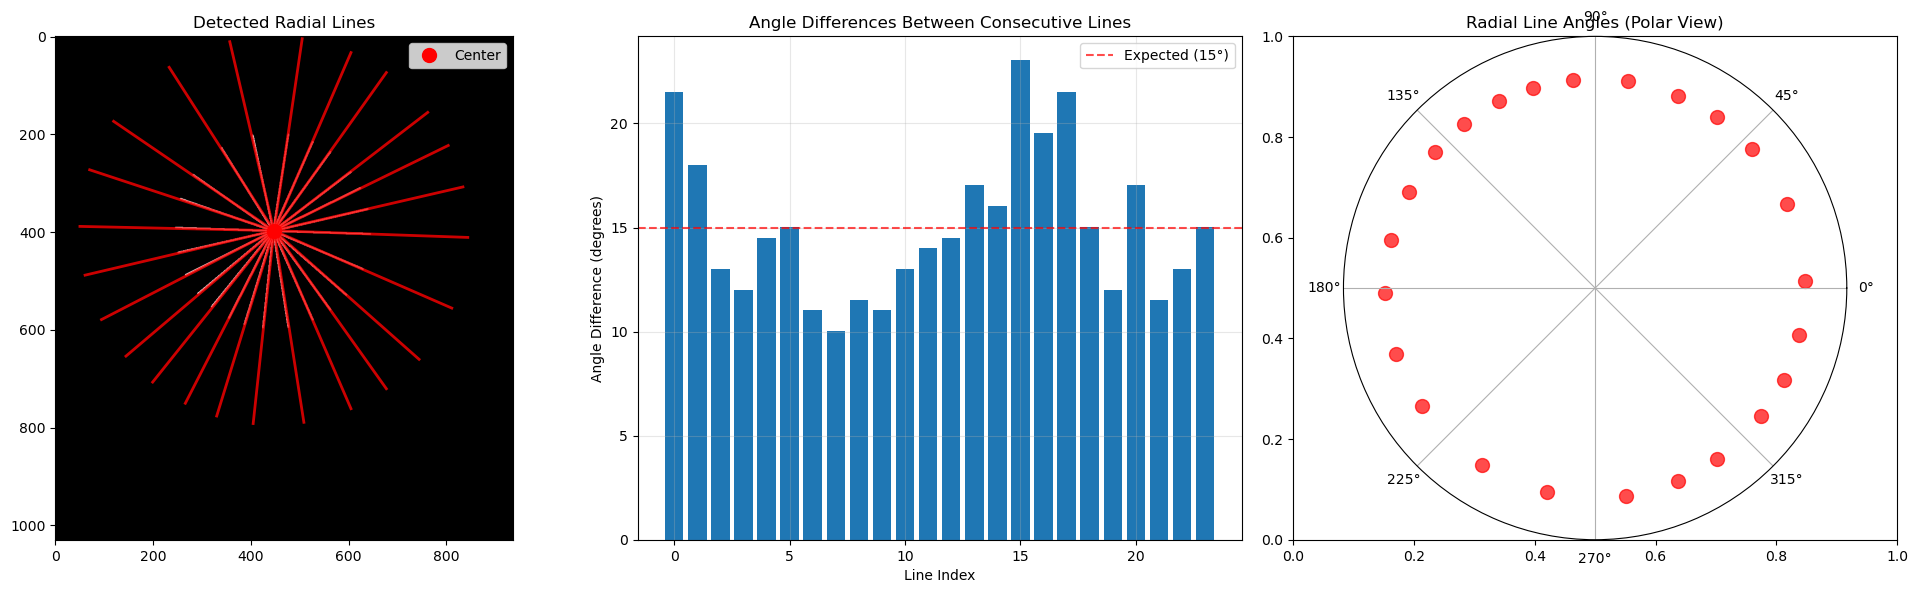

Number of radial lines detected: 24
Center point: (447, 397)
Detected angles: [  2.00278164  23.53268428  41.55771905  54.57579972  66.59248957
  81.11265647  96.13351878 107.1488178  117.16272601 128.67872045
 139.69401947 152.71210014 166.73157163 181.25173853 198.27538248
 214.29763561 237.32962448 256.85674548 278.38664812 293.40751043
 305.42420028 322.44784423 333.96383866 346.98191933]
Angle differences: [21.52990264 18.02503477 13.01808067 12.01668985 14.5201669  15.02086231
 11.01529903 10.01390821 11.51599444 11.01529903 13.01808067 14.01947149
 14.5201669  17.02364395 16.02225313 23.03198887 19.527121   21.52990264
 15.02086231 12.01668985 17.02364395 11.51599444 13.01808067 15.02086231]
Mean angle difference: 15.00°
Standard deviation: 3.54°
Expected angle difference (360°/24): 15.00°

Expected angle difference for 24 lines: 15.00°
⚠ Lines may not be evenly spaced


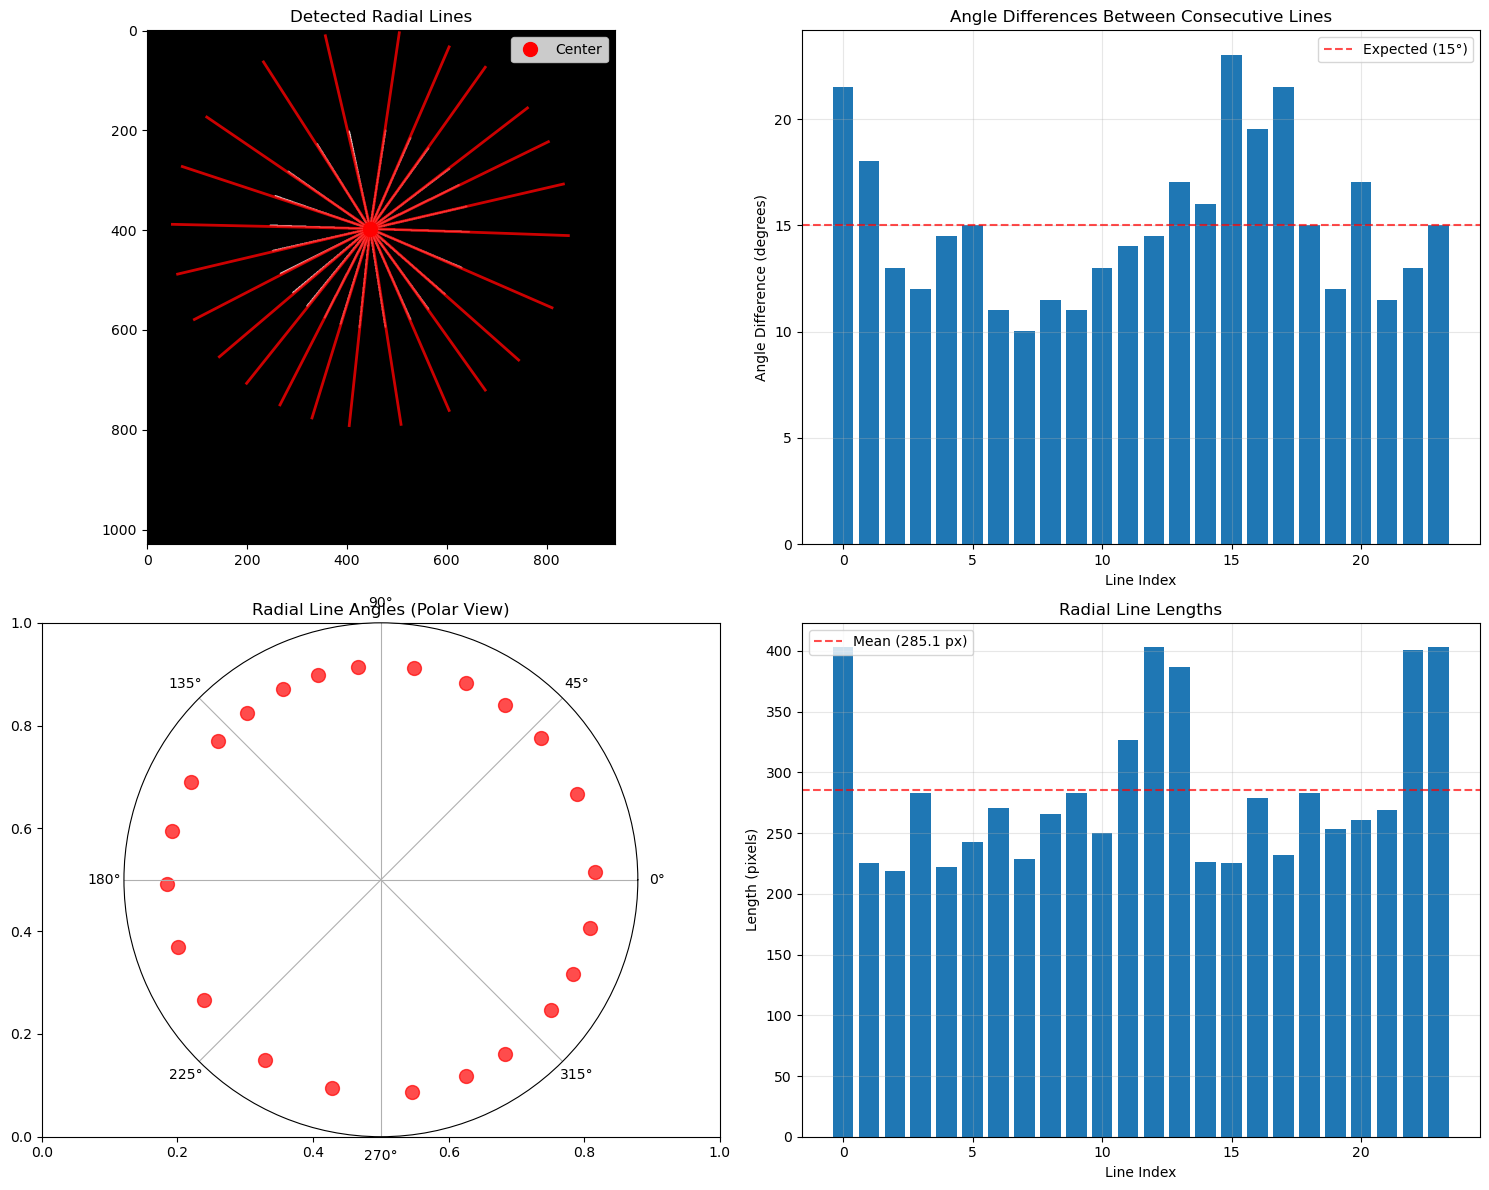

Number of radial lines detected: 24
Center point: (447, 397)
Detected angles: [  2.00278164  23.53268428  41.55771905  54.57579972  66.59248957
  81.11265647  96.13351878 107.1488178  117.16272601 128.67872045
 139.69401947 152.71210014 166.73157163 181.25173853 198.27538248
 214.29763561 237.32962448 256.85674548 278.38664812 293.40751043
 305.42420028 322.44784423 333.96383866 346.98191933]
Angle differences: [21.52990264 18.02503477 13.01808067 12.01668985 14.5201669  15.02086231
 11.01529903 10.01390821 11.51599444 11.01529903 13.01808067 14.01947149
 14.5201669  17.02364395 16.02225313 23.03198887 19.527121   21.52990264
 15.02086231 12.01668985 17.02364395 11.51599444 13.01808067 15.02086231]
Mean angle difference: 15.00°
Standard deviation: 3.54°
Expected angle difference (360°/24): 15.00°

Line Length Statistics:
Lengths: [403 225 219 283 222 243 271 229 266 283 250 327 403 387 226 225 279 232
 283 253 261 269 401 403]
Mean length: 285.1 pixels
Standard deviation: 63.8 pixels
M

In [25]:
results = analyze_radial_lines(mask)
visualize_results(mask, results)
# To measure lengths:
lengths = measure_radial_line_lengths(mask, results['center'], results['angles'])
results['lengths'] = lengths
results['mean_length'] = np.mean(lengths)
results['std_length'] = np.std(lengths)
results['min_length'] = np.min(lengths)
results['max_length'] = np.max(lengths)
visualize_results(mask, results, show_lengths=True)

In [9]:
#Finding web area in pixels
def count_white_pixels(image: np.ndarray) -> int:
    """
    Count the number of white pixels in a binarized RGB image.

    Args:
        image (np.ndarray): Binarized RGB image as a NumPy array of shape (H, W, 3).
                            White pixels are [255, 255, 255].

    Returns:
        int: Number of white pixels.
    """
    # Create a boolean mask where all channels are 255 (white)
    white_mask = np.all(image == 255, axis=-1)
    
    # Count True values in the mask
    return np.sum(white_mask)


In [10]:
web_area = count_white_pixels(image = web)
print("Web area is " + str(web_area) + " pixels")

Web area is 260298 pixels
